## 1. Import Required Libraries
We start by loading the essential Python libraries:

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

sns.set_style('whitegrid')

## 2. Load and Inspect the Dataset
We read the `aapl_data.csv` file into a pandas DataFrame.

In [ ]:
df = pd.read_csv('../data/aapl_data_data.csv', sep='\\t')
df.head()

C:\Users\100si\AppData\Local\Temp\ipykernel_26716\3115550258.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('../data/aapl_data.csv', sep='\\t')


,Date,Open,High,Low,Close,Adj Close,Volume,Name
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.562591,493729600,AAPL
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.573935,601904800,AAPL
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.469369,552160000,AAPL
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.457407,477131200,AAPL
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.500339,447610800,AAPL


Keep only AAPL rows

In [ ]:

df = df[df['Name'] == 'aapl_data_stock'].copy()

## 3. Data Inspection
We check the dataset:
- `info()` tells us info
- `isnull().sum()` counts missing values
- `describe()` gives a summary

In [10]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2943 entries, 0 to 2942
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2943 non-null   str    
 1   Open       2943 non-null   float64
 2   High       2943 non-null   float64
 3   Low        2943 non-null   float64
 4   Close      2943 non-null   float64
 5   Adj Close  2943 non-null   float64
 6   Volume     2943 non-null   int64  
 7   Name       2943 non-null   str    
dtypes: float64(5), int64(1), str(2)
memory usage: 184.1 KB


,Open,High,Low,Close,Adj Close,Volume
count,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2.943000e+03
mean,39.709515,40.118886,39.297271,39.723350,38.004553,2.750651e+08
std,33.703053,34.099196,33.297867,33.713824,34.211791,2.269062e+08
min,6.870357,7.000000,6.794643,6.858929,5.889189,4.544800e+07
25%,18.173928,18.380894,18.002143,18.197321,15.903871,1.119810e+08
50%,27.857500,28.117500,27.527500,27.932501,25.756020,1.890336e+08
75%,46.587502,47.028749,46.261251,46.641251,45.175106,3.765776e+08
max,156.979996,157.259995,154.389999,156.690002,156.690002,1.880998e+09


## 4. Date Range
We extract the first and last day to understand the period.

In [11]:
print("Earliest date:", df['Date'].min())
print("Latest date:", df['Date'].max())

Earliest date: 2010-01-04
Latest date: 2021-09-10


(Removes duplicate date)

In [12]:
df = df.drop_duplicates(subset='Date', keep='last')
df.sort_values('Date', inplace=True)

## 5. Closing Price Trend
A simple line chart of closing prices over time reveals the big picture:

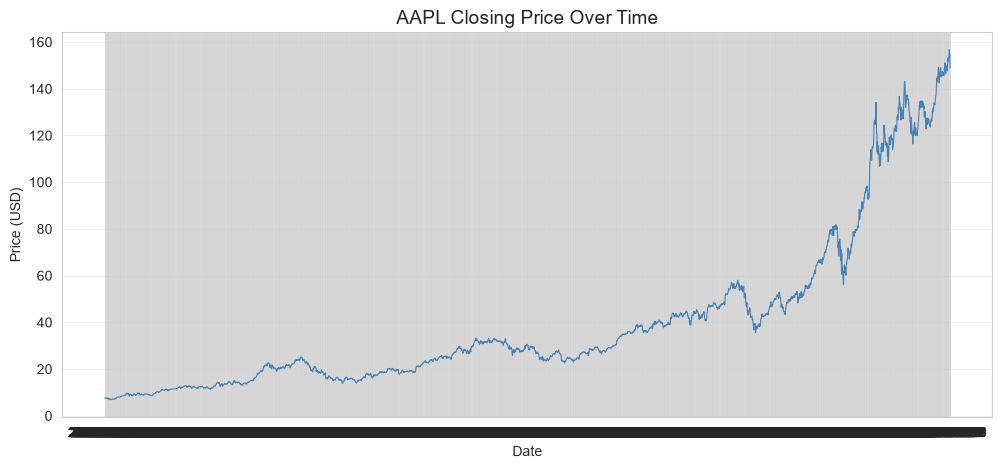

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], linewidth=0.8, color='steelblue')
plt.title('aapl_data_stock Closing Price Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Daily Returns Distribution
**Daily return** = percentage change from one close to the next.

In [14]:
# Remove any previous Daily_Return column to avoid conflicts
df['Date'] = pd.to_datetime(df['Date'])

# 2. Calculate daily returns from Adjusted Close
df['Daily_Return'] = df['Adj Close'].pct_change() * 100

# 3. Find the indices of the maximum and minimum return
max_idx = df['Daily_Return'].idxmax()
min_idx = df['Daily_Return'].idxmin()

# 4. Print the results (now safe)
print(f"📈 Best day  : +{df.loc[max_idx, 'Daily_Return']:.2f}% on {df.loc[max_idx, 'Date'].date()}")
print(f"📉 Worst day :  {df.loc[min_idx, 'Daily_Return']:.2f}% on {df.loc[min_idx, 'Date'].date()}")


📈 Best day  : +11.98% on 2020-03-13
📉 Worst day :  -12.86% on 2020-03-16


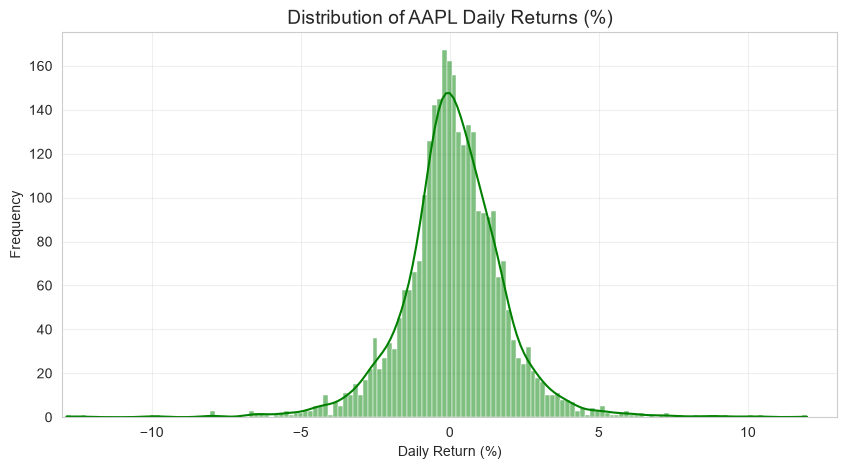

In [ ]:
# Calculate daily percentage change
df['Daily_Return'] = df['Close'].pct_change() * 100

# Plot histogram of daily returns
plt.figure(figsize=(10, 5))
sns.histplot(df['Daily_Return'].dropna(), bins=150, kde=True, color='green')
plt.title('Distribution of aapl_data_stock Daily Returns (%)', fontsize=14)
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.xlim(-13, 13)  
plt.show()

## 7. 30‑Day Rolling Volatility
Volatility = standard deviation of daily returns over a rolling window.

d:\stocks-python-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


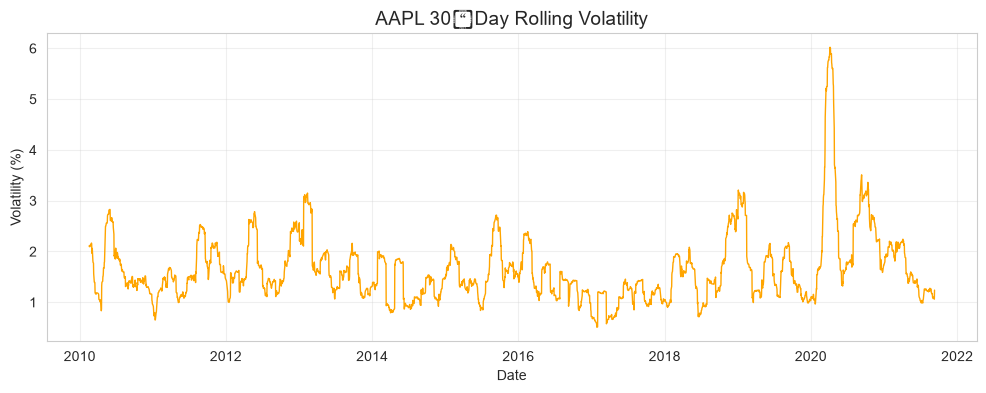

In [ ]:
# 30-day rolling standard deviation of daily returns
df['Rolling_Vol_30'] = df['Daily_Return'].rolling(30).std()

# Plot rolling volatility
plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['Rolling_Vol_30'], color='orange', linewidth=1)
plt.title('aapl_data_stock 30‑Day Rolling Volatility', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.grid(True, alpha=0.3)
plt.show()

## 8. CAGR
 CAGR = (Ending Value / Starting Value) ^ (1 / Number of Years) - 1

In [17]:
start_price = df['Adj Close'].iloc[0]
end_price = df['Adj Close'].iloc[-1]

# Calculate number of years between first and last date
num_days = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days
num_years = num_days / 365.25

# Calculate CAGR
cagr = (end_price / start_price) ** (1 / num_years) - 1

print(f"Start Date: {df['Date'].iloc[0].date()} | Price: ${start_price:.2f}")
print(f"End Date:   {df['Date'].iloc[-1].date()} | Price: ${end_price:.2f}")
print(f"Period: {num_years:.1f} years")
print(f"\n📈 CAGR: {cagr:.2%}")

Start Date: 2010-01-04 | Price: $6.56
End Date:   2021-09-10 | Price: $148.97
Period: 11.7 years

📈 CAGR: 30.64%


## 9. Maximum Drawdown
Drawdown = (Current Price - Peak Price) / Peak Price

Worst Drawdown: -43.80%
Peak: $21.62 on 2012-09-19
Trough: $12.15 on 2013-04-19


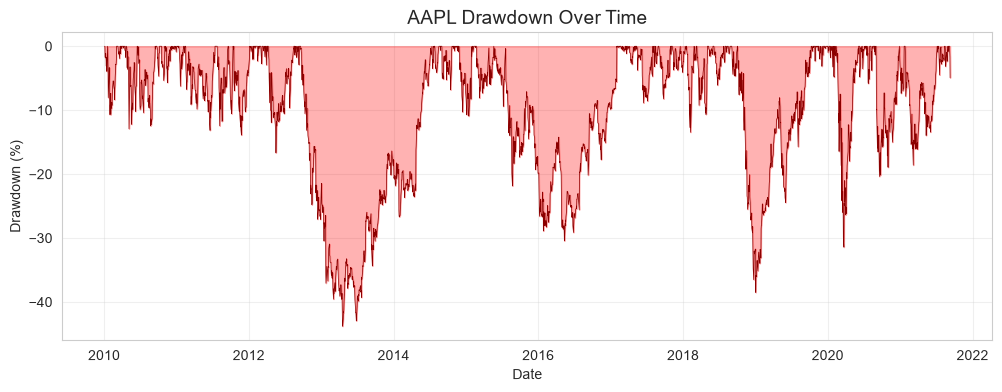

In [ ]:

# Calculate running peak (highest price up to each date)
df['Running_Peak'] = df['Adj Close'].cummax()

# Calculate drawdown from the peak at each point
df['Drawdown'] = (df['Adj Close'] - df['Running_Peak']) / df['Running_Peak']

# Find the maximum drawdown (most negative value)
max_dd = df['Drawdown'].min()
max_dd_idx = df['Drawdown'].idxmin()
max_dd_date = df.loc[max_dd_idx, 'Date']

# Find the peak that preceded this drawdown
peak_date = df.loc[:max_dd_idx, 'Adj Close'].idxmax()
peak_price = df.loc[peak_date, 'Adj Close']
trough_price = df.loc[max_dd_idx, 'Adj Close']

print(f"Worst Drawdown: {max_dd:.2%}")
print(f"Peak: ${peak_price:.2f} on {df.loc[peak_date, 'Date'].date()}")
print(f"Trough: ${trough_price:.2f} on {max_dd_date.date()}")

# Plot the drawdown over time
plt.figure(figsize=(12, 4))
plt.fill_between(df['Date'], df['Drawdown'] * 100, 0, color='red', alpha=0.3)
plt.plot(df['Date'], df['Drawdown'] * 100, color='darkred', linewidth=0.5)
plt.title('aapl_data_stock Drawdown Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)
plt.show()